# LLM-Based Material Transport Simulation

**マップ**: `/Game/Maps/Level`

**前提**: Unreal Engine でレベルを Play 状態にしてから実行してください。

## シナリオ概要

1. Humanoid（作業管理者）とロボット（SpotDog）を同じ場所にスポーン
2. 搬送対象のマテリアル（Box）を指定位置にスポーン
3. **Humanoid が LLM を使い、ロボットへの搬送指示を生成**
4. ロボットがその指示を解析・実行:
   - Phase 1: マテリアル置き場へ移動
   - Phase 2: マテリアルをピックアップ（取得シミュレーション）
   - Phase 3: ホームベースへ帰還・マテリアルを降ろす
5. 軌跡データを記録して可視化

## LLM 指示生成フロー

```
Humanoid (LLM)
  └─ システムプロンプト: 倉庫管理者ロール
  └─ ユーザープロンプト: マテリアル位置 + ロボット位置 + ホーム位置
  └─ 出力 (JSON): { material_location, return_location, task_description }
        ↓
RobotExecutor
  └─ IDLE → NAVIGATING_TO_MATERIAL → PICKING_UP → CARRYING → NAVIGATING_HOME → DROPPING → DONE
```

In [1]:
import math
import socket
import subprocess
import sys
import threading
import time
from enum import Enum
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydantic import BaseModel

# SimWorld ルートをパスに追加。
# Notebook 実行時はカレントディレクトリが変わるため、親ディレクトリを探索して特定する。
def _find_project_root() -> Path:
    search_starts = []
    if "__file__" in globals():
        search_starts.append(Path(__file__).resolve().parent)
    search_starts.append(Path.cwd().resolve())

    for start in search_starts:
        for candidate in (start, *start.parents):
            if (candidate / "setup.py").exists() and (candidate / "simworld").is_dir():
                return candidate

    if "__file__" in globals():
        return Path(__file__).resolve().parent.parent.parent
    return Path.cwd().resolve()


_root = _find_project_root()
sys.path.append(str(_root))
_output_dir = Path(__file__).resolve().parent if "__file__" in globals() else (_root / "dev" / "llm_material_transport")

from dotenv import load_dotenv

# プロジェクトルートの .env を読み込む (OPENROUTER_API_KEY などを環境変数に設定)
_env_path = _root / ".env"
if _env_path.exists():
    load_dotenv(_env_path)
    print(f"[.env] Loaded from {_env_path}")
else:
    print(f"[.env] Not found at {_env_path} — using system environment variables.")

from simworld.agent.humanoid import Humanoid
from simworld.communicator.communicator import Communicator
from simworld.communicator.unrealcv import UnrealCV
from simworld.llm.a2a_llm import A2ALLM
from simworld.utils.vector import Vector

ucv = None
communicator = None

UE_PORT = 9000


def _is_wsl() -> bool:
    version_path = Path("/proc/version")
    if not version_path.exists():
        return False
    text = version_path.read_text(encoding="utf-8").lower()
    return "microsoft" in text or "wsl" in text


def _wsl_default_gateway_ip() -> Optional[str]:
    """WSL2 から Windows ホスト (vEthernet) へのデフォルトゲートウェイ IP。"""
    try:
        result = subprocess.run(
            ["ip", "route", "show", "default"],
            capture_output=True,
            text=True,
            timeout=3,
            check=False,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    parts = result.stdout.split()
    if len(parts) >= 3 and parts[0] == "default" and parts[1] == "via":
        return parts[2]
    return None


def _windows_host_ip_from_resolv() -> Optional[str]:
    """/etc/resolv.conf の nameserver（WSL では DNS プロキシで TCP には使えないことが多い）。"""
    resolv_path = Path("/etc/resolv.conf")
    if not resolv_path.exists():
        return None
    for line in resolv_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line.startswith("nameserver"):
            parts = line.split()
            if len(parts) >= 2:
                return parts[1]
    return None


def _ue_host_candidates() -> List[str]:
    hosts: List[str] = []
    if _is_wsl():
        for candidate in (_wsl_default_gateway_ip(), _windows_host_ip_from_resolv()):
            if candidate and candidate not in hosts:
                hosts.append(candidate)
        if "127.0.0.1" not in hosts:
            hosts.append("127.0.0.1")
        return hosts
    hosts.append("127.0.0.1")
    resolv_ip = _windows_host_ip_from_resolv()
    if resolv_ip and resolv_ip not in hosts:
        hosts.append(resolv_ip)
    return hosts


def _probe_unrealcv_endpoint(host: str, port: int = UE_PORT, timeout: float = 2.0) -> bool:
    """TCP 接続先が UnrealCV サーバかどうかをバナーで確認する。"""
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.settimeout(timeout)
    try:
        sock.connect((host, port))
        banner = sock.recv(64)
        return b"connected" in banner
    except OSError:
        return False
    finally:
        sock.close()


def _port_listener_hint(port: int = UE_PORT) -> str:
    """127.0.0.1:port を LISTEN しているプロセスの ss 行を返す（診断用）。"""
    try:
        result = subprocess.run(
            ["ss", "-tlnp"],
            capture_output=True,
            text=True,
            timeout=3,
            check=False,
        )
    except (OSError, subprocess.SubprocessError):
        return ""
    needle = f":{port}"
    lines = [line for line in result.stdout.splitlines() if needle in line and "LISTEN" in line]
    return "; ".join(lines[:2])


def ensure_connection() -> Tuple[UnrealCV, Communicator]:
    """UnrealCV/Communicator を必要時に初期化して返す。"""
    global ucv, communicator

    if ucv is not None and ucv.client.isconnected():
        if communicator is None or communicator.unrealcv is not ucv:
            communicator = Communicator(ucv)
        return ucv, communicator

    if ucv is not None:
        try:
            ucv.disconnect()
        except Exception:
            pass
        ucv = None
        communicator = None

    errors: List[str] = []
    for host in _ue_host_candidates():
        if not _probe_unrealcv_endpoint(host, UE_PORT):
            extra = ""
            if host == "127.0.0.1":
                hint = _port_listener_hint(UE_PORT)
                if hint:
                    extra = f" (listener: {hint})"
            errors.append(f"{host}:{UE_PORT} — not UnrealCV{extra}")
            continue
        try:
            ucv = UnrealCV(port=UE_PORT, ip=host)
            communicator = Communicator(ucv)
            print(f"[UE] Connected via UnrealCV at {host}:{UE_PORT}")
            return ucv, communicator
        except Exception as exc:
            errors.append(f"{host}:{UE_PORT} — {exc}")
            if ucv is not None:
                try:
                    ucv.disconnect()
                except Exception:
                    pass
            ucv = None
            communicator = None

    shadow_hint = _port_listener_hint(UE_PORT)
    shadow_note = ""
    if shadow_hint and "python" in shadow_hint.lower():
        shadow_note = (
            "\n\n[WSL] 127.0.0.1:9000 が WSL 内の Python に占有されています。"
            " Notebook カーネルを Restart し、Windows で SimWorld.exe を起動してから"
            " 初期設定セル → UE 接続セルの順で再実行してください。"
        )

    raise ConnectionError(
        "Unreal Engine (UnrealCV) に接続できませんでした。\n"
        "1. Windows PowerShell で UE サーバを起動:\n"
        "     cd C:\\SimWorldServer\n"
        "     .\\SimWorld.exe -windowed -log /Game/Maps/Level\n"
        "2. ログに `Start listening on port 9000` があるか確認\n"
        "3. この Notebook で Kernel → Restart 後、初期設定セルを実行してから UE 接続セルを実行\n"
        "試行結果:\n  - " + "\n  - ".join(errors)
        + shadow_note
    )


plt.style.use("seaborn-v0_8-whitegrid")

[.env] Loaded from /home/winder17wsl_ishizawalab/00_kotaprivate/Program/SimWorld/.env


In [2]:
# ==============================================================
# シミュレーション設定
# ==============================================================

# ---- エージェントアセットパス ----
HUMAN_BP_PATH    = "/Game/TrafficSystem/Pedestrian/Base_User_Agent.Base_User_Agent_C"
ROBOT_BP_PATH    = "/Game/Robot_Dog/Blueprint/BP_SpotRobot.BP_SpotRobot_C"

ROBOT_NAME = "MT_SpotRobot"

# SpotDog 側には humanoid のような PickUp API が公開されていないため、
# 現状は「持ち上げアニメーション」ではなく、軽量物体を前方に保持して運ぶ演出に寄せる。
MATERIAL_PRESET = "box"  # "mug" | "box"
MATERIAL_PRESETS = {
    "mug": {
        "bp_path": "/Game/InteractableAsset/Cup/BP_Mug.BP_Mug_C",
        "name": "MT_MaterialMug",
        "label": "mug",
        "scale": (1.0, 1.0, 1.0),
        "carry_forward_cm": -5.0,
        "carry_side_cm": -20.0,
        "carry_z_cm": 92.0,
        "carry_proxy_bp_path": "/Game/CityDatabase/blueprints/BP_Box.BP_Box_C",
        "carry_proxy_name": "MT_MaterialMugCarryProxy",
        "carry_proxy_scale": (0.22, 0.22, 0.22),
        "drop_z_cm": 6.0,
    },
    "box": {
        "bp_path": "/Game/InteractableAsset/Box/BP_Interactable_Box.BP_Interactable_Box_C",
        "name": "MT_MaterialBox",
        "label": "box",
        "scale": (0.5, 0.5, 0.5),
        "carry_forward_cm": 0.0,
        "carry_side_cm": 0.0,
        "carry_z_cm": 60.0,
        "drop_z_cm": 20.0,
    },
}

if MATERIAL_PRESET not in MATERIAL_PRESETS:
    raise ValueError(f"Unsupported MATERIAL_PRESET: {MATERIAL_PRESET}")

_material_config = MATERIAL_PRESETS[MATERIAL_PRESET]
MATERIAL_BP_PATH = _material_config["bp_path"]
MATERIAL_NAME = _material_config["name"]
MATERIAL_LABEL = _material_config["label"]
MATERIAL_SCALE = _material_config["scale"]
MATERIAL_CARRY_FORWARD_CM = _material_config["carry_forward_cm"]
MATERIAL_CARRY_SIDE_CM = _material_config["carry_side_cm"]
MATERIAL_CARRY_Z_CM = _material_config["carry_z_cm"]
MATERIAL_CARRY_PROXY_BP_PATH = _material_config.get("carry_proxy_bp_path")
MATERIAL_CARRY_PROXY_NAME = _material_config.get("carry_proxy_name")
MATERIAL_CARRY_PROXY_SCALE = _material_config.get("carry_proxy_scale", MATERIAL_SCALE)
USE_MATERIAL_CARRY_PROXY = MATERIAL_CARRY_PROXY_BP_PATH is not None
MATERIAL_DROP_Z_CM = _material_config["drop_z_cm"]
KNOWN_MATERIAL_NAMES = list(dict.fromkeys(
    config["name"]
    for config in MATERIAL_PRESETS.values()
    if isinstance(config.get("name"), str)
))
KNOWN_MATERIAL_PROXY_NAMES = list(dict.fromkeys(
    config["carry_proxy_name"]
    for config in MATERIAL_PRESETS.values()
    if isinstance(config.get("carry_proxy_name"), str)
))
KNOWN_MATERIAL_ACTOR_NAMES = list(dict.fromkeys(KNOWN_MATERIAL_NAMES + KNOWN_MATERIAL_PROXY_NAMES))
MATERIAL_HIDDEN_Z_CM = -5000.0
MATERIAL_HIDDEN_SCALE = (0.01, 0.01, 0.01)

# ---- スポーンレイアウト設定 ----
# "anchor":   ANCHOR_XYZ 周辺に Human / Robot / Material を配置
# "boundary": 境界矩形と辺の指定から境界付近の座標を自動生成
# "manual":   下の MANUAL_* 座標をそのまま使用
SPAWN_LAYOUT_MODE = "anchor"

# ---- アンカー配置 (/Game/Maps/Level 作業エリア) [cm] ----
ANCHOR_XYZ = (1725.755, -1011.4, 3812.825)
ROBOT_LATERAL_OFFSET_CM = 200.0   # Human と Robot の横方向間隔 [cm]（約 2 m）
MATERIAL_DISTANCE_CM = 2000.0     # Human から Material までの距離 [cm]（約 20 m、右斜め前方）

# 全スポーン位置への共通オフセット [cm]（UE: +X=前方, +Y=右, +Z=高さ）
SPAWN_OFFSET_LEFT_CM = 700.0    # 左へ 7 m（当初 2 m + さらに 5 m）
SPAWN_OFFSET_BACK_CM = 300.0    # 後ろへ 3 m（-X）
SPAWN_OFFSET_HEIGHT_CM = 100.0  # 高さ +1 m（+Z）

# 境界矩形 (min_x, max_x, min_y, max_y) [cm]
# NOTE: /Game/Maps/Level の作業領域に合わせて適宜調整してください
LEVEL_BOUNDS_XYXY = (0.0, 2400.0, 0.0, 1400.0)
BOUNDARY_EDGE = "west"     # "west" | "east" | "south" | "north"
BOUNDARY_INSET_CM = 200.0   # 境界から内側へ入れる距離 [cm]
ROBOT_LEAD_CM = 120.0       # Human より少し前方に置く距離 [cm]
MATERIAL_FORWARD_CM = 700.0 # Human 基準の前方オフセット [cm]
MATERIAL_SIDE_CM = 250.0    # Human 基準の横方向オフセット [cm]

# ---- 手動スポーン位置 (x, y, z) [cm] ----
MANUAL_HUMAN_SPAWN    = (200.0, 200.0, 100.0)
MANUAL_ROBOT_SPAWN    = (300.0, 200.0,  20.0)
MANUAL_MATERIAL_SPAWN = (1200.0, 600.0, 20.0)


def _clamp(value: float, lower: float, upper: float) -> float:
    return max(lower, min(upper, value))


def apply_global_spawn_offset(
    xyz: Tuple[float, float, float],
    left_cm: float = SPAWN_OFFSET_LEFT_CM,
    back_cm: float = SPAWN_OFFSET_BACK_CM,
    height_cm: float = SPAWN_OFFSET_HEIGHT_CM,
) -> Tuple[float, float, float]:
    """Human / Robot / Material 共通の位置オフセットを適用する。"""
    x, y, z = (float(xyz[0]), float(xyz[1]), float(xyz[2]))
    return (x - back_cm, y - left_cm, z + height_cm)


def apply_global_spawn_offset_to_layout(
    human_spawn: Tuple[float, float, float],
    robot_spawn: Tuple[float, float, float],
    material_spawn: Tuple[float, float, float],
    home_xy: Tuple[float, float],
) -> Tuple[Tuple[float, float, float], Tuple[float, float, float], Tuple[float, float, float], Tuple[float, float]]:
    human_spawn = apply_global_spawn_offset(human_spawn)
    robot_spawn = apply_global_spawn_offset(robot_spawn)
    material_spawn = apply_global_spawn_offset(material_spawn)
    return human_spawn, robot_spawn, material_spawn, human_spawn[:2]


def build_boundary_spawn_layout(
    bounds_xyxy: Tuple[float, float, float, float],
    edge: str,
    inset_cm: float,
    robot_lead_cm: float,
    material_forward_cm: float,
    material_side_cm: float,
    human_z: float = 100.0,
    robot_z: float = 20.0,
    material_z: float = 20.0,
) -> Tuple[Tuple[float, float, float], Tuple[float, float, float], Tuple[float, float, float], Tuple[float, float]]:
    """境界矩形と辺の指定から、境界寄りの spawn 配置を生成する。"""
    min_x, max_x, min_y, max_y = (float(value) for value in bounds_xyxy)
    if not (min_x < max_x and min_y < max_y):
        raise ValueError("LEVEL_BOUNDS_XYXY must satisfy min_x < max_x and min_y < max_y")

    center_x = (min_x + max_x) / 2.0
    center_y = (min_y + max_y) / 2.0
    edge = edge.lower()

    if edge == "west":
        home_xy = (min_x + inset_cm, center_y)
        robot_xy = (home_xy[0] + robot_lead_cm, home_xy[1])
        material_xy = (home_xy[0] + material_forward_cm, home_xy[1] + material_side_cm)
    elif edge == "east":
        home_xy = (max_x - inset_cm, center_y)
        robot_xy = (home_xy[0] - robot_lead_cm, home_xy[1])
        material_xy = (home_xy[0] - material_forward_cm, home_xy[1] + material_side_cm)
    elif edge == "south":
        home_xy = (center_x, min_y + inset_cm)
        robot_xy = (home_xy[0], home_xy[1] + robot_lead_cm)
        material_xy = (home_xy[0] + material_side_cm, home_xy[1] + material_forward_cm)
    elif edge == "north":
        home_xy = (center_x, max_y - inset_cm)
        robot_xy = (home_xy[0], home_xy[1] - robot_lead_cm)
        material_xy = (home_xy[0] + material_side_cm, home_xy[1] - material_forward_cm)
    else:
        raise ValueError(f"Unsupported BOUNDARY_EDGE: {edge}")

    inset_min_x = min_x + inset_cm
    inset_max_x = max_x - inset_cm
    inset_min_y = min_y + inset_cm
    inset_max_y = max_y - inset_cm

    home_xy = (
        _clamp(home_xy[0], inset_min_x, inset_max_x),
        _clamp(home_xy[1], inset_min_y, inset_max_y),
    )
    robot_xy = (
        _clamp(robot_xy[0], inset_min_x, inset_max_x),
        _clamp(robot_xy[1], inset_min_y, inset_max_y),
    )
    material_xy = (
        _clamp(material_xy[0], inset_min_x, inset_max_x),
        _clamp(material_xy[1], inset_min_y, inset_max_y),
    )

    human_spawn = (home_xy[0], home_xy[1], human_z)
    robot_spawn = (robot_xy[0], robot_xy[1], robot_z)
    material_spawn = (material_xy[0], material_xy[1], material_z)
    return human_spawn, robot_spawn, material_spawn, home_xy


def build_anchor_spawn_layout(
    anchor_xyz: Tuple[float, float, float],
    robot_lateral_cm: float,
    material_distance_cm: float,
) -> Tuple[Tuple[float, float, float], Tuple[float, float, float], Tuple[float, float, float], Tuple[float, float]]:
    """アンカー座標周辺に Human / Robot / Material を配置する。

    - Human: アンカー位置
    - Robot: Human と同じ X・Z、+Y 方向へ横並び
    - Material: Human から右斜め前方（+X, +Y）へ material_distance_cm（45°）
    """
    ax, ay, az = (float(anchor_xyz[0]), float(anchor_xyz[1]), float(anchor_xyz[2]))
    human_spawn = (ax, ay, az)
    robot_spawn = (ax, ay + robot_lateral_cm, az)
    diagonal_cm = material_distance_cm / math.sqrt(2.0)
    material_spawn = (ax + diagonal_cm, ay + diagonal_cm, az)
    home_xy = (ax, ay)
    return human_spawn, robot_spawn, material_spawn, home_xy


if SPAWN_LAYOUT_MODE == "anchor":
    HUMAN_SPAWN, ROBOT_SPAWN, MATERIAL_SPAWN, HOME_XY = build_anchor_spawn_layout(
        anchor_xyz=ANCHOR_XYZ,
        robot_lateral_cm=ROBOT_LATERAL_OFFSET_CM,
        material_distance_cm=MATERIAL_DISTANCE_CM,
    )
elif SPAWN_LAYOUT_MODE == "boundary":
    HUMAN_SPAWN, ROBOT_SPAWN, MATERIAL_SPAWN, HOME_XY = build_boundary_spawn_layout(
        bounds_xyxy=LEVEL_BOUNDS_XYXY,
        edge=BOUNDARY_EDGE,
        inset_cm=BOUNDARY_INSET_CM,
        robot_lead_cm=ROBOT_LEAD_CM,
        material_forward_cm=MATERIAL_FORWARD_CM,
        material_side_cm=MATERIAL_SIDE_CM,
    )
else:
    HUMAN_SPAWN = MANUAL_HUMAN_SPAWN
    ROBOT_SPAWN = MANUAL_ROBOT_SPAWN
    MATERIAL_SPAWN = MANUAL_MATERIAL_SPAWN
    HOME_XY = HUMAN_SPAWN[:2]

HUMAN_SPAWN, ROBOT_SPAWN, MATERIAL_SPAWN, HOME_XY = apply_global_spawn_offset_to_layout(
    HUMAN_SPAWN, ROBOT_SPAWN, MATERIAL_SPAWN, HOME_XY,
)

_spawn_edge = BOUNDARY_EDGE if SPAWN_LAYOUT_MODE == "boundary" else "n/a"
print(
    f"[SpawnLayout] mode={SPAWN_LAYOUT_MODE}, edge={_spawn_edge}, material={MATERIAL_PRESET}, "
    f"offset=(left={SPAWN_OFFSET_LEFT_CM}cm, back={SPAWN_OFFSET_BACK_CM}cm, "
    f"height={SPAWN_OFFSET_HEIGHT_CM}cm), "
    f"human={HUMAN_SPAWN}, robot={ROBOT_SPAWN}, material_spawn={MATERIAL_SPAWN}"
)

# ---- LLM 設定 ----
# OpenRouter を使用 (無料枠あり)。
# https://openrouter.ai/ でアカウント登録 → API キー取得 → 環境変数 OPENROUTER_API_KEY に設定
# `openrouter/free` は現在利用可能な無料モデル群へ自動ルーティングする。
# 個別の `:free` モデル名は頻繁に入れ替わるため、デモ既定値としてはこちらを使う。
LLM_MODEL    = "openrouter/free"
LLM_PROVIDER = "openrouter"

# ---- ロボット移動パラメータ ----
ROBOT_SPEED       = 200    # 移動速度 [UE 単位]
ROBOT_MOVE_SLICE  = 0.2    # 1 スライスの移動時間 [s]
ROBOT_TURN_DUR    = 1.0    # 回頭 1 回の時間 [s]
ROTATE_THR_DEG    = 20.0   # この角度差以上でのみ回転する閾値 [deg]
ARRIVE_TOLERANCE  = 120.0  # 目的地到達判定距離 [cm]
PICKUP_HOVER_Z    = 60.0   # 搬送中のマテリアル高さオフセット [cm]

# ---- 記録設定 ----
RECORD_INTERVAL  = 0.3    # データ記録間隔 [s]

[SpawnLayout] mode=boundary, edge=west, material=box, human=(200.0, 700.0, 100.0), robot=(320.0, 700.0, 20.0), material_spawn=(900.0, 950.0, 20.0)


In [4]:
# ==============================================================
# UE 接続
# ==============================================================
# Unreal Engine でレベルを Play してから、このセルを実行してください
ensure_connection()

(<simworld.communicator.unrealcv.UnrealCV at 0x76289cd0bee0>,
 <simworld.communicator.communicator.Communicator at 0x762792c4f970>)

In [5]:
# ==============================================================
# LLM クライアント (Humanoid が使用)
# ==============================================================
llm = A2ALLM(model_name=LLM_MODEL, provider=LLM_PROVIDER)

2026-05-26 11:16:08,256 - SimWorld.BaseLLM - INFO - Initialized LLM client for model -- openrouter/free, url -- https://openrouter.ai/api/v1


In [6]:
# ==============================================================
# データモデル: LLM が出力するタスク指示
# ==============================================================

class RobotTaskInstruction(BaseModel):
    """Humanoid LLM が生成するロボットへの搬送指示。"""
    material_location: List[float]   # マテリアルの XY 座標 [cm]
    return_location:   List[float]   # 帰還先の XY 座標 [cm]
    task_description:  str           # 人間が読むタスク説明
    priority:          str = "normal"  # "normal" or "urgent"

In [7]:
# ==============================================================
# ロボット状態機械
# ==============================================================

class RobotState(Enum):
    IDLE                   = 0
    NAVIGATING_TO_MATERIAL = 1
    PICKING_UP             = 2
    CARRYING               = 3
    NAVIGATING_HOME        = 4
    DROPPING               = 5
    DONE                   = 6

In [8]:
# ==============================================================
# ユーティリティ関数
# ==============================================================

def normalize_angle(deg: float) -> float:
    """角度を [-180, 180] に正規化。"""
    while deg > 180:
        deg -= 360
    while deg < -180:
        deg += 360
    return deg


def get_pos2d(actor_name: str) -> Tuple[float, float]:
    """UE アクターの XY 位置 [cm] を取得。"""
    loc = ucv.get_location(actor_name)
    return float(loc[0]), float(loc[1])


def get_pos3d(actor_name: str) -> Tuple[float, float, float]:
    """UE アクターの XYZ 位置 [cm] を取得。"""
    loc = ucv.get_location(actor_name)
    return float(loc[0]), float(loc[1]), float(loc[2])


def get_yaw(actor_name: str) -> float:
    """UE アクターの Yaw 角 [deg] を取得。"""
    ori = ucv.get_orientation(actor_name)
    return float(ori[1])


def yaw_to_target(from_xy: Tuple[float, float], to_xy: Tuple[float, float]) -> float:
    """ある位置からターゲットへの方位角 [deg] を計算。"""
    dx = to_xy[0] - from_xy[0]
    dy = to_xy[1] - from_xy[1]
    return math.degrees(math.atan2(dy, dx))


def dist2d(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    """2D 距離 [cm] を計算。"""
    return math.hypot(a[0] - b[0], a[1] - b[1])


def get_map_object_positions(
    name_contains: Optional[str] = None,
    limit: Optional[int] = 50,
    include_rotation: bool = False,
) -> pd.DataFrame:
    """マップ内オブジェクトの位置一覧を DataFrame で返す。"""
    active_ucv, _ = ensure_connection()

    actor_names = sorted(str(name) for name in active_ucv.get_objects().tolist())
    if name_contains:
        needle = name_contains.lower()
        actor_names = [name for name in actor_names if needle in name.lower()]
    if limit is not None:
        actor_names = actor_names[:limit]

    rows = []
    for actor_name in actor_names:
        try:
            location = tuple(float(value) for value in active_ucv.get_location(actor_name))
            row = {
                "actor_name": actor_name,
                "x": round(location[0], 1),
                "y": round(location[1], 1),
                "z": round(location[2], 1),
            }
            if include_rotation:
                rotation = tuple(float(value) for value in active_ucv.get_orientation(actor_name))
                row.update({
                    "pitch": round(rotation[0], 1),
                    "yaw": round(rotation[1], 1),
                    "roll": round(rotation[2], 1),
                })
            rows.append(row)
        except Exception as exc:
            rows.append({
                "actor_name": actor_name,
                "error": str(exc),
            })

    return pd.DataFrame(rows)


def cleanup_material_transport_spawned_objects(
    remove_all_generated_humanoids: bool = True,
    dry_run: bool = False,
) -> dict:
    """このシナリオで生成した actor を削除し、Humanoid の ID カウンタを戻す。"""
    active_ucv, active_communicator = ensure_connection()
    existing_objects = {str(name) for name in active_ucv.get_objects().tolist()}

    candidate_names = []
    if remove_all_generated_humanoids:
        candidate_names.extend(
            sorted(name for name in existing_objects if name.startswith("GEN_BP_Humanoid_"))
        )

    tracked_names = [globals().get("HUMAN_NAME"), ROBOT_NAME, *KNOWN_MATERIAL_ACTOR_NAMES]
    for actor_name in tracked_names:
        if isinstance(actor_name, str) and actor_name in existing_objects:
            candidate_names.append(actor_name)

    candidate_names = list(dict.fromkeys(candidate_names))
    print(f"[Cleanup] candidates={candidate_names}")

    if dry_run:
        return {"candidates": candidate_names, "destroyed": [], "errors": {}}

    destroyed = []
    errors = {}
    for actor_name in candidate_names:
        try:
            if actor_name.startswith("GEN_BP_Humanoid_"):
                try:
                    active_ucv.humanoid_stop(actor_name)
                except Exception:
                    pass
            active_ucv.destroy(actor_name)
            destroyed.append(actor_name)
        except Exception as exc:
            errors[actor_name] = str(exc)

    active_ucv.clean_garbage()

    from simworld.agent.humanoid import Humanoid

    Humanoid._id_counter = 0
    Humanoid._camera_id_counter = 1
    active_communicator.humanoid_id_to_name.clear()

    print(f"[Cleanup] destroyed={destroyed}")
    if errors:
        print(f"[Cleanup] errors={errors}")
    return {"candidates": candidate_names, "destroyed": destroyed, "errors": errors}


def get_robot_carry_pose() -> Tuple[Tuple[float, float, float], Tuple[float, float, float]]:
    """現在の SpotDog 前方に、軽量物体を保持して見える位置と向きを返す。"""
    robot_x, robot_y, robot_z = get_pos3d(ROBOT_NAME)
    robot_yaw = get_yaw(ROBOT_NAME)
    yaw_rad = math.radians(robot_yaw)

    forward_x = math.cos(yaw_rad)
    forward_y = math.sin(yaw_rad)
    side_x = -math.sin(yaw_rad)
    side_y = math.cos(yaw_rad)

    carry_loc = (
        robot_x + MATERIAL_CARRY_FORWARD_CM * forward_x + MATERIAL_CARRY_SIDE_CM * side_x,
        robot_y + MATERIAL_CARRY_FORWARD_CM * forward_y + MATERIAL_CARRY_SIDE_CM * side_y,
        robot_z + MATERIAL_CARRY_Z_CM,
    )
    carry_rot = (0.0, robot_yaw, 0.0)
    return carry_loc, carry_rot


def actor_exists(actor_name: Optional[str]) -> bool:
    """指定した actor が UE 上に存在するかを返す。"""
    if not actor_name:
        return False
    return actor_name in {str(name) for name in ucv.get_objects().tolist()}


def destroy_actor_if_exists(actor_name: Optional[str]) -> None:
    """存在する場合のみ actor を削除する。"""
    if actor_exists(actor_name):
        ucv.destroy(actor_name)


def get_material_tracking_name() -> str:
    """現在シーン上で可視な搬送対象 actor 名を返す。"""
    if USE_MATERIAL_CARRY_PROXY and actor_exists(MATERIAL_CARRY_PROXY_NAME):
        return MATERIAL_CARRY_PROXY_NAME
    return MATERIAL_NAME


def hide_material_actor(actor_name: Optional[str]) -> None:
    """実マテリアルを画面外へ退避して carry 中に見えないようにする。"""
    if not actor_exists(actor_name):
        return

    actor_x, actor_y, _ = ucv.get_location(actor_name)
    hidden_loc = (float(actor_x), float(actor_y), MATERIAL_HIDDEN_Z_CM)
    ucv.set_collision(actor_name, False)
    ucv.set_physics(actor_name, False)
    ucv.set_movable(actor_name, True)
    ucv.set_location(hidden_loc, actor_name)
    ucv.set_orientation((0.0, 0.0, 0.0), actor_name)
    ucv.set_scale(MATERIAL_HIDDEN_SCALE, actor_name)


def spawn_material_actor(location: Tuple[float, float, float], enable_physics: bool = True) -> str:
    """マテリアル本体 actor を指定位置へ生成する。"""
    active_ucv, _ = ensure_connection()
    if not actor_exists(MATERIAL_NAME):
        active_ucv.spawn_bp_asset(MATERIAL_BP_PATH, MATERIAL_NAME)
    active_ucv.set_location(location, MATERIAL_NAME)
    active_ucv.set_orientation((0.0, 0.0, 0.0), MATERIAL_NAME)
    active_ucv.set_scale(MATERIAL_SCALE, MATERIAL_NAME)
    active_ucv.set_collision(MATERIAL_NAME, True)
    active_ucv.set_movable(MATERIAL_NAME, True)
    active_ucv.set_physics(MATERIAL_NAME, enable_physics)
    return MATERIAL_NAME


def spawn_material_carry_proxy() -> Optional[str]:
    """必要なら搬送中の可視プロキシ actor を生成する。"""
    if not USE_MATERIAL_CARRY_PROXY:
        return None

    active_ucv, _ = ensure_connection()
    if not actor_exists(MATERIAL_CARRY_PROXY_NAME):
        active_ucv.spawn_bp_asset(MATERIAL_CARRY_PROXY_BP_PATH, MATERIAL_CARRY_PROXY_NAME)
        active_ucv.set_scale(MATERIAL_CARRY_PROXY_SCALE, MATERIAL_CARRY_PROXY_NAME)
        active_ucv.set_collision(MATERIAL_CARRY_PROXY_NAME, False)
        active_ucv.set_movable(MATERIAL_CARRY_PROXY_NAME, True)
        active_ucv.set_physics(MATERIAL_CARRY_PROXY_NAME, False)
    return MATERIAL_CARRY_PROXY_NAME


def sync_carried_material_pose() -> None:
    """現在の SpotDog 姿勢に合わせて保持中マテリアルの見た目を更新する。"""
    actor_name = MATERIAL_NAME
    if USE_MATERIAL_CARRY_PROXY:
        actor_name = spawn_material_carry_proxy() or MATERIAL_NAME

    carry_loc, carry_rot = get_robot_carry_pose()
    ucv.set_location(carry_loc, actor_name)
    ucv.set_orientation(carry_rot, actor_name)

In [9]:
# ==============================================================
# スポーン関数
# ==============================================================

def spawn_human() -> Humanoid:
    """Humanoid（作業管理者）をスポーンする。"""
    _, active_communicator = ensure_connection()
    human = Humanoid(
        position=Vector(HUMAN_SPAWN[0], HUMAN_SPAWN[1]),
        direction=Vector(1, 0),
    )
    active_communicator.spawn_agent(
        agent=human,
        name=None,
        position=HUMAN_SPAWN,
        model_path=HUMAN_BP_PATH,
        type="humanoid",
    )
    print(f"  [Human] spawned at {HUMAN_SPAWN[:2]}")
    return human


def spawn_robot() -> str:
    """SpotDog ロボットをスポーンしてアクター名を返す。"""
    active_ucv, _ = ensure_connection()
    active_ucv.spawn_bp_asset(ROBOT_BP_PATH, ROBOT_NAME)
    active_ucv.set_location(ROBOT_SPAWN, ROBOT_NAME)
    active_ucv.set_orientation((0, 0, 0), ROBOT_NAME)
    active_ucv.set_collision(ROBOT_NAME, True)
    active_ucv.set_movable(ROBOT_NAME, True)
    active_ucv.enable_controller(ROBOT_NAME, True)
    print(f"  [Robot] spawned at {ROBOT_SPAWN[:2]}")
    return ROBOT_NAME


def spawn_material() -> str:
    """搬送対象マテリアルをスポーンしてアクター名を返す。"""
    for actor_name in KNOWN_MATERIAL_PROXY_NAMES:
        destroy_actor_if_exists(actor_name)
    for actor_name in KNOWN_MATERIAL_NAMES:
        if actor_name != MATERIAL_NAME:
            destroy_actor_if_exists(actor_name)
    spawn_material_actor(MATERIAL_SPAWN, enable_physics=True)
    print(f"  [Material:{MATERIAL_LABEL}] spawned at {MATERIAL_SPAWN[:2]}")
    return MATERIAL_NAME

In [10]:
# ==============================================================
# LLM 指示生成 (Humanoid → Robot)
# ==============================================================

TASK_SYSTEM_PROMPT = """\
You are a warehouse supervisor managing a robotic transport system.
You observe the positions of the robot and materials in the warehouse.
Your job is to issue clear, structured task instructions to the transport robot.
Return exactly one JSON object with concrete task values.
Do not return a JSON schema, field definitions, markdown, or explanatory text.
"""

TASK_USER_PROMPT = """\
Current warehouse status:
- Human operator (you) is at position: ({hx:.0f}, {hy:.0f}) cm
- Transport robot (SpotDog) is at position: ({rx:.0f}, {ry:.0f}) cm
- Material "{mat_name}" ({mat_label}) is located at position: ({mx:.0f}, {my:.0f}) cm

Task: Issue an instruction to the robot to:
1. Navigate to the material location
2. Pick up the material
3. Transport it back to the operator's home base at ({hx:.0f}, {hy:.0f}) cm

Generate a robot task instruction in JSON format.
Use the actual coordinates from this task.
Return an object with this shape:
{{
    "material_location": [x, y],
    "return_location": [x, y],
    "task_description": "short imperative instruction",
    "priority": "normal"
}}
Do not return schema keys such as "properties", "required", "title", or "description".
"""


def generate_task_instruction(
    human: Humanoid,
    human_name: str,
    robot_pos: Tuple[float, float],
) -> Optional[RobotTaskInstruction]:
    """
    Humanoid が LLM を呼び出し、ロボットへの搬送タスク指示を生成する。

    Returns:
        RobotTaskInstruction or None if LLM call fails.
    """
    hx, hy = get_pos2d(human_name)
    rx, ry = robot_pos
    mx, my = MATERIAL_SPAWN[0], MATERIAL_SPAWN[1]

    # Humanoid が指示生成前にジェスチャーを実行
    ucv.humanoid_directing_path(human_name)
    time.sleep(1.5)

    user_prompt = TASK_USER_PROMPT.format(
        hx=hx, hy=hy, rx=rx, ry=ry,
        mx=mx, my=my, mat_name=MATERIAL_NAME, mat_label=MATERIAL_LABEL,
    )

    print("\n[Humanoid LLM] Generating task instruction...")
    response, call_time = llm.generate_instructions(
        system_prompt=TASK_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        response_format=RobotTaskInstruction,
    )
    print(f"[Humanoid LLM] Response (in {call_time:.2f}s):\n{response}")

    if response is None:
        print("[Humanoid LLM] ERROR: LLM returned None. Falling back to default instruction.")
        return RobotTaskInstruction(
            material_location=[mx, my],
            return_location=[hx, hy],
            task_description=(
                f"Go to ({mx:.0f}, {my:.0f}) and pick up the {MATERIAL_LABEL}, "
                f"then return to ({hx:.0f}, {hy:.0f})."
            ),
            priority="normal",
        )

    import json as _json
    try:
        data = _json.loads(response) if isinstance(response, str) else response
        return RobotTaskInstruction(**data) if isinstance(data, dict) else RobotTaskInstruction.model_validate(data)
    except Exception as e:
        print(f"[Humanoid LLM] Parse error: {e}. Using fallback.")
        return RobotTaskInstruction(
            material_location=[mx, my],
            return_location=[hx, hy],
            task_description=f"Fallback: pick up the {MATERIAL_LABEL} and return.",
            priority="normal",
        )

In [11]:
# ==============================================================
# ロボット自律ナビゲーション
# ==============================================================

def robot_navigate_to(
    target_xy: Tuple[float, float],
    stop_event: threading.Event,
    tolerance_cm: float = ARRIVE_TOLERANCE,
    label: str = "",
) -> bool:
    """
    ルールベースでロボットを target_xy まで移動させる。
    障害物回避なし（シンプル直進 + 回転）。

    Returns:
        True if arrived, False if interrupted by stop_event.
    """
    print(f"  [Robot] Navigating to {target_xy} {label}")
    while not stop_event.is_set():
        pos = get_pos2d(ROBOT_NAME)
        d   = dist2d(pos, target_xy)
        if d <= tolerance_cm:
            print(f"  [Robot] Arrived at {target_xy} (dist={d:.1f} cm)")
            return True

        yaw        = get_yaw(ROBOT_NAME)
        target_yaw = yaw_to_target(pos, target_xy)
        angle_diff = normalize_angle(target_yaw - yaw)

        if abs(angle_diff) > ROTATE_THR_DEG:
            # 目標方向へ回頭
            clockwise = 1 if angle_diff < 0 else -1
            ucv.dog_rotate(ROBOT_NAME, [ROBOT_TURN_DUR, abs(angle_diff), clockwise])
        else:
            # 前進
            ucv.dog_move(ROBOT_NAME, [ROBOT_SPEED, ROBOT_MOVE_SLICE, 0])

    return False  # interrupted


def robot_simulate_pickup(stop_event: threading.Event) -> None:
    """
    ロボットがマテリアルをピックアップする演出。
    SpotDog 用の PickUp API はないため、軽量物体を背上に保持する。
    """
    print(f"  [Robot] Picking up {MATERIAL_LABEL}...")
    time.sleep(1.0)
    if USE_MATERIAL_CARRY_PROXY:
        hide_material_actor(MATERIAL_NAME)
        spawn_material_carry_proxy()
    else:
        ucv.set_collision(MATERIAL_NAME, False)
        ucv.set_physics(MATERIAL_NAME, False)
    sync_carried_material_pose()
    time.sleep(1.0)
    print(f"  [Robot] {MATERIAL_LABEL} picked up.")


def robot_carry_material(stop_event: threading.Event) -> None:
    """
    ロボット移動中、マテリアルをロボット背上位置に追従させるスレッド用関数。
    stop_event がセットされるまでループ。
    """
    while not stop_event.is_set():
        sync_carried_material_pose()
        time.sleep(0.02)
    sync_carried_material_pose()


def robot_simulate_drop(home_xy: Tuple[float, float]) -> None:
    """
    ロボットがホームベースでマテリアルを降ろすアニメーション。
    """
    print(f"  [Robot] Dropping {MATERIAL_LABEL} at home base...")
    time.sleep(1.0)
    # マテリアルをホーム付近に配置し、物理を再有効化
    drop_location = (home_xy[0] + 80, home_xy[1], MATERIAL_DROP_Z_CM)
    if USE_MATERIAL_CARRY_PROXY:
        destroy_actor_if_exists(MATERIAL_CARRY_PROXY_NAME)
        spawn_material_actor(drop_location, enable_physics=True)
    else:
        ucv.set_location(drop_location, MATERIAL_NAME)
        ucv.set_orientation((0.0, 0.0, 0.0), MATERIAL_NAME)
        ucv.set_collision(MATERIAL_NAME, True)
        ucv.set_physics(MATERIAL_NAME, True)
    time.sleep(0.5)
    print(f"  [Robot] {MATERIAL_LABEL} dropped.")

In [12]:
# ==============================================================
# ロボット搬送タスク実行
# ==============================================================

def execute_transport_task(
    instruction: RobotTaskInstruction,
    human_name: str,
    sim_data: List[dict],
    stop_event: threading.Event,
) -> RobotState:
    """
    搬送タスク全体を実行する状態機械。

    Returns:
        最終 RobotState。
    """
    state     = RobotState.IDLE
    mat_loc   = (instruction.material_location[0], instruction.material_location[1])
    home_loc  = (instruction.return_location[0],   instruction.return_location[1])

    print(f"\n[Robot] Task received: {instruction.task_description}")
    print(f"  material={mat_loc}, home={home_loc}, priority={instruction.priority}")

    # Humanoid がロボットに手を振る
    ucv.humanoid_wave_to_dog(human_name)
    time.sleep(1.0)

    # --- Phase 1: マテリアル置き場へ移動 ---
    state = RobotState.NAVIGATING_TO_MATERIAL
    print(f"\n[Robot] State: {state.name}")
    arrived = robot_navigate_to(mat_loc, stop_event, label="(material location)")
    if not arrived:
        return state

    # --- Phase 2: ピックアップ ---
    state = RobotState.PICKING_UP
    print(f"\n[Robot] State: {state.name}")
    robot_simulate_pickup(stop_event)

    # --- Phase 3: ホームへ搬送 ---
    state = RobotState.CARRYING
    print(f"\n[Robot] State: {state.name}")

    carry_stop = threading.Event()
    t_carry    = threading.Thread(target=robot_carry_material, args=(carry_stop,), daemon=True)
    t_carry.start()

    arrived = robot_navigate_to(home_loc, stop_event, label="(home base)")
    carry_stop.set()
    t_carry.join(timeout=2)

    if not arrived:
        return state

    # --- Phase 4: 降ろす ---
    state = RobotState.NAVIGATING_HOME
    print(f"\n[Robot] State: {state.name}")

    state = RobotState.DROPPING
    print(f"\n[Robot] State: {state.name}")
    robot_simulate_drop(home_loc)

    # Humanoid がロボットの帰還を確認してジェスチャー
    ucv.humanoid_discuss(human_name, 0)
    time.sleep(1.0)

    state = RobotState.DONE
    print(f"\n[Robot] State: {state.name} — Task complete!")
    return state

In [13]:
# ==============================================================
# データ記録スレッド
# ==============================================================

def recorder_loop(
    human_name: str,
    sim_data: List[dict],
    stop_event: threading.Event,
    t_start: float,
) -> None:
    """RECORD_INTERVAL 秒ごとに各エージェントの位置を記録。"""
    while not stop_event.is_set():
        t         = time.time() - t_start
        robot_pos = get_pos2d(ROBOT_NAME)
        human_pos = get_pos2d(human_name)
        try:
            mat_pos = get_pos2d(get_material_tracking_name())
        except Exception:
            mat_pos = (float("nan"), float("nan"))
        dist_hr   = dist2d(human_pos, robot_pos)
        dist_rm   = dist2d(robot_pos, mat_pos)
        sim_data.append({
            "t":        t,
            "human_x":  human_pos[0],
            "human_y":  human_pos[1],
            "robot_x":  robot_pos[0],
            "robot_y":  robot_pos[1],
            "mat_x":    mat_pos[0],
            "mat_y":    mat_pos[1],
            "dist_human_robot_cm": dist_hr,
            "dist_robot_mat_cm":   dist_rm,
        })
        time.sleep(RECORD_INTERVAL)

In [14]:
# --- 既存のスポーン済み actor を削除してから再実行したい場合 ---
cleanup_result = cleanup_material_transport_spawned_objects()
human = None
HUMAN_NAME = None
instruction = None
print(cleanup_result)

[Cleanup] candidates=[]
[Cleanup] destroyed=[]
{'candidates': [], 'destroyed': [], 'errors': {}}


In [20]:
# ==============================================================
# メイン: スポーン → LLM 指示 → 実行
# ==============================================================

print("=== Spawning agents and material ===")
human  = spawn_human()
HUMAN_NAME = communicator.get_humanoid_name(human.id)
spawn_robot()
spawn_material()
time.sleep(3.0)   # スポーン完了 + 物理安定待ち

print(f"\n=== Spawn complete  human={HUMAN_NAME}  robot={ROBOT_NAME}  material={MATERIAL_NAME} ===\n")

INFO:__init__:238:Got connection confirm: b'connected to SimWorld'


=== Spawning agents and material ===
=>Info: using ip-port socket
[UE] Connected via UnrealCV at 172.20.224.1:9000
(200.0, 700.0, 100.0)
  [Human] spawned at (200.0, 700.0)
  [Robot] spawned at (320.0, 700.0)
  [Material:box] spawned at (900.0, 950.0)

=== Spawn complete  human=GEN_BP_Humanoid_0  robot=MT_SpotRobot  material=MT_MaterialBox ===



In [28]:
# --- Debug: UE 内の actor / camera 座標確認 ---
ensure_connection()


def _parse_vector3(raw_value) -> Tuple[float, float, float]:
    if isinstance(raw_value, str):
        return tuple(float(token) for token in raw_value.replace(",", " ").split()[:3])
    return tuple(float(token) for token in raw_value[:3])


print("=== Debug: actor and camera positions ===")
print("[Configured spawn positions]")
print(f"  SPAWN_LAYOUT_MODE = {SPAWN_LAYOUT_MODE}")
if SPAWN_LAYOUT_MODE == "boundary":
    print(f"  LEVEL_BOUNDS_XYXY = {LEVEL_BOUNDS_XYXY}")
    print(f"  BOUNDARY_EDGE     = {BOUNDARY_EDGE}")
    print(f"  BOUNDARY_INSET_CM = {BOUNDARY_INSET_CM}")
print(f"  HUMAN_SPAWN    = {HUMAN_SPAWN}")
print(f"  ROBOT_SPAWN    = {ROBOT_SPAWN}")
print(f"  MATERIAL_SPAWN = {MATERIAL_SPAWN}")

print("\n[Actual actor transforms in UE]")
for label, actor_name in (("Human", HUMAN_NAME), ("Robot", ROBOT_NAME), ("Material", MATERIAL_NAME)):
    loc = tuple(np.round(ucv.get_location(actor_name), 1))
    rot = tuple(np.round(ucv.get_orientation(actor_name), 1))
    print(f"  {label:8s} {actor_name}: location={loc}, rotation={rot}")

raw_cameras = ucv.get_cameras()
camera_names = raw_cameras.split() if isinstance(raw_cameras, str) else list(raw_cameras)

print(f"\n[Available cameras] raw={raw_cameras}")
if camera_names:
    for camera_id, camera_name in enumerate(camera_names):
        try:
            cam_loc = _parse_vector3(ucv.get_camera_location(camera_id))
            cam_rot = _parse_vector3(ucv.get_camera_rotation(camera_id))
            print(f"  camera {camera_id} ({camera_name}): location={cam_loc}, rotation={cam_rot}")
        except Exception as exc:
            print(f"  camera {camera_id} ({camera_name}): transform 取得失敗 ({exc})")
else:
    print("  camera 一覧を取得できませんでした。raw 出力を確認してください。")

print("\n[Tips]")
print(f"  - UE Outliner で {HUMAN_NAME}, {ROBOT_NAME}, {MATERIAL_NAME} を検索すると見つけやすいです。")
print("  - 上の camera 座標は SimWorld / UnrealCV が管理しているゲーム内カメラです。")

=== Debug: actor and camera positions ===
[Configured spawn positions]
  SPAWN_LAYOUT_MODE = boundary
  LEVEL_BOUNDS_XYXY = (0.0, 2400.0, 0.0, 1400.0)
  BOUNDARY_EDGE     = west
  BOUNDARY_INSET_CM = 200.0
  HUMAN_SPAWN    = (200.0, 700.0, 100.0)
  ROBOT_SPAWN    = (320.0, 700.0, 20.0)
  MATERIAL_SPAWN = (900.0, 950.0, 20.0)

[Actual actor transforms in UE]
  Human    GEN_BP_Humanoid_0: location=(np.float64(200.0), np.float64(700.0), np.float64(-148.4)), rotation=(np.float64(0.0), np.float64(0.0), np.float64(0.0))
  Robot    MT_SpotRobot: location=(np.float64(320.0), np.float64(700.0), np.float64(-188.4)), rotation=(np.float64(0.0), np.float64(0.0), np.float64(0.0))
  Material MT_MaterialBox: location=(np.float64(900.0), np.float64(950.0), np.float64(20.0)), rotation=(np.float64(0.0), np.float64(0.0), np.float64(0.0))

[Available cameras] raw=PawnSensor ThirdPersonCamera FusionCamSensor 
  camera 0 (PawnSensor): location=(1725.755, -1011.4, 3812.825), rotation=(-3.847, -62.971, 0.0)
  

In [17]:
# --- LLM 指示生成 ---
robot_initial_pos = get_pos2d(ROBOT_NAME)
instruction = generate_task_instruction(human, HUMAN_NAME, robot_initial_pos)
print(f"\n[Instruction] {instruction}")


[Humanoid LLM] Generating task instruction...


2026-05-26 11:16:31,256 - SimWorld.A2ALLM - INFO - user_content: [{'type': 'text', 'text': 'Current warehouse status:\n- Human operator (you) is at position: (200, 700) cm\n- Transport robot (SpotDog) is at position: (320, 700) cm\n- Material "MT_MaterialBox" (box) is located at position: (900, 950) cm\n\nTask: Issue an instruction to the robot to:\n1. Navigate to the material location\n2. Pick up the material\n3. Transport it back to the operator\'s home base at (200, 700) cm\n\nGenerate a robot task instruction in JSON format.\nUse the actual coordinates from this task.\nReturn an object with this shape:\n{\n    "material_location": [x, y],\n    "return_location": [x, y],\n    "task_description": "short imperative instruction",\n    "priority": "normal"\n}\nDo not return schema keys such as "properties", "required", "title", or "description".\n\nPlease respond in valid JSON format following this schema: {"description": "Humanoid LLM が生成するロボットへの搬送指示。", "properties": {"material_locatio

[Humanoid LLM] Response (in 17.89s):
{'material_location': [900, 950], 'return_location': [200, 700], 'task_description': "Retrieve MT_MaterialBox and return to operator's home base", 'priority': 'normal'}

[Instruction] material_location=[900.0, 950.0] return_location=[200.0, 700.0] task_description="Retrieve MT_MaterialBox and return to operator's home base" priority='normal'


In [18]:
# --- 記録 + タスク実行 ---
sim_data: List[dict] = []
stop_event = threading.Event()
t_start    = time.time()

# 記録スレッド開始
t_rec = threading.Thread(
    target=recorder_loop,
    args=(HUMAN_NAME, sim_data, stop_event, t_start),
    daemon=True,
)
t_rec.start()

# ロボット搬送タスク実行（メインスレッドで順次実行）
final_state = execute_transport_task(instruction, HUMAN_NAME, sim_data, stop_event)

# 記録停止
stop_event.set()
t_rec.join(timeout=3)

print(f"\n=== Task finished with state: {final_state.name} ===")
print(f"=== {len(sim_data)} data points recorded ===")


[Robot] Task received: Retrieve MT_MaterialBox and return to operator's home base
  material=(900.0, 950.0), home=(200.0, 700.0), priority=normal

[Robot] State: NAVIGATING_TO_MATERIAL
  [Robot] Navigating to (900.0, 950.0) (material location)
  [Robot] Arrived at (900.0, 950.0) (dist=105.1 cm)

[Robot] State: PICKING_UP
  [Robot] Picking up box...
  [Robot] box picked up.

[Robot] State: CARRYING
  [Robot] Navigating to (200.0, 700.0) (home base)
  [Robot] Arrived at (200.0, 700.0) (dist=113.3 cm)

[Robot] State: NAVIGATING_HOME

[Robot] State: DROPPING
  [Robot] Dropping box at home base...
  [Robot] box dropped.

[Robot] State: DONE — Task complete!

=== Task finished with state: DONE ===
=== 43 data points recorded ===


In [19]:
# ==============================================================
# クリーンアップ
# ==============================================================
cleanup_result = cleanup_material_transport_spawned_objects()
human = None
HUMAN_NAME = None
instruction = None
print(cleanup_result)
ucv.disconnect()
print("=== UE disconnected ===")

[Cleanup] candidates=['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox']
[Cleanup] destroyed=['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox']
{'candidates': ['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox'], 'destroyed': ['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox'], 'errors': {}}
=== UE disconnected ===


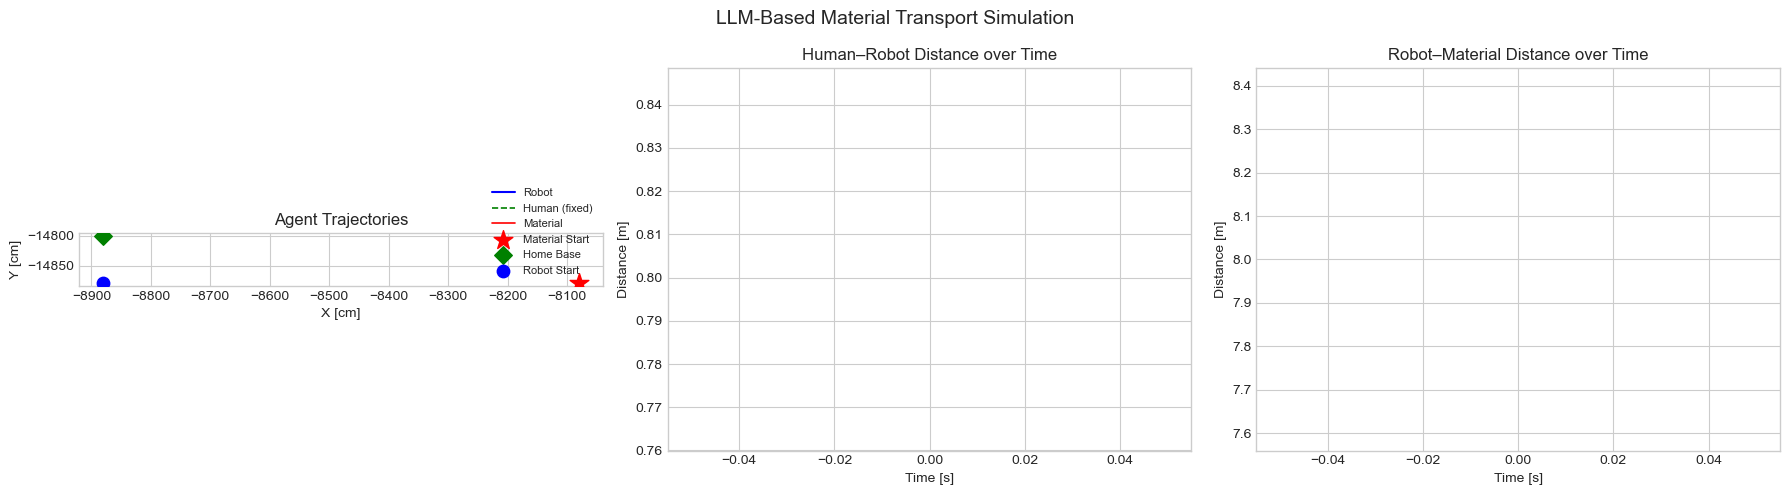

Figure saved: C:\Users\thewi\Dropbox\03_ARCHES\01_main\01_HRC\03_simulation\SimWorld\dev\llm_material_transport\result.png


In [18]:
# ==============================================================
# 結果可視化
# ==============================================================

df = pd.DataFrame(sim_data)

if df.empty:
    print("No data recorded.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("LLM-Based Material Transport Simulation", fontsize=14)

    # --- (1) 軌跡プロット ---
    ax = axes[0]
    ax.plot(df["robot_x"], df["robot_y"], "b-", lw=1.5, label="Robot")
    ax.plot(df["human_x"], df["human_y"], "g--", lw=1.2, label="Human (fixed)")
    ax.plot(df["mat_x"],   df["mat_y"],   "r-",  lw=1.2, label="Material")
    ax.scatter(*MATERIAL_SPAWN[:2], c="red",   marker="*", s=200, zorder=5, label="Material Start")
    ax.scatter(*HOME_XY,             c="green", marker="D", s=80,  zorder=5, label="Home Base")
    ax.scatter(df["robot_x"].iloc[0], df["robot_y"].iloc[0],
               c="blue", marker="o", s=80, zorder=5, label="Robot Start")
    ax.set_xlabel("X [cm]")
    ax.set_ylabel("Y [cm]")
    ax.set_title("Agent Trajectories")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")

    # --- (2) 時系列: Human-Robot 距離 ---
    ax = axes[1]
    ax.plot(df["t"], df["dist_human_robot_cm"] / 100.0, "purple", lw=1.5)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Distance [m]")
    ax.set_title("Human–Robot Distance over Time")

    # --- (3) 時系列: Robot-Material 距離 ---
    ax = axes[2]
    ax.plot(df["t"], df["dist_robot_mat_cm"] / 100.0, "orange", lw=1.5)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Distance [m]")
    ax.set_title("Robot–Material Distance over Time")

    plt.tight_layout()
    output_path = _output_dir / "result.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f"Figure saved: {output_path}")